# Logistic Regression 4 - Evaluation & Thresholds (Beginner-Friendly Lab)

> **MLCourse · Machine Learning · 02_logistic_regression**

Accuracy alone lies. This lab teaches you to READ a classifier using four
tools - confusion matrix, precision, recall, ROC/AUC - through stories, then
moves the decision threshold on REAL model outputs like practitioners do.

## What you'll learn
- The 2×2 confusion matrix as four plain-English outcomes
- Precision vs recall via a smoke-detector story (and when each hurts)
- F1: the one-number compromise
- ROC curve & AUC without formulas-first thinking
- Moving the 0.5 threshold deliberately for business goals

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, recall_score,
                             f1_score, roc_curve, auc, RocCurveDisplay)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

## 1. The four outcomes - a smoke-detector story

| | alarm SOUNDS (pred 1) | stays silent (pred 0) |
#|---|---|---|
#| **fire** (true 1) | ✅ true positive - saved you | ❌ **false negative** - burned house |
#| **no fire** (true 0) | ❌ **false positive** - annoying shower | ✅ true negative - quiet night |

Every metric below is arithmetic on these four cells.

,TP,FN,FP,TN
count,89,1,1,52
plain English,correctly flagged malignant,MISSED cancer (worst case!),false alarm on healthy patient,correctly cleared healthy


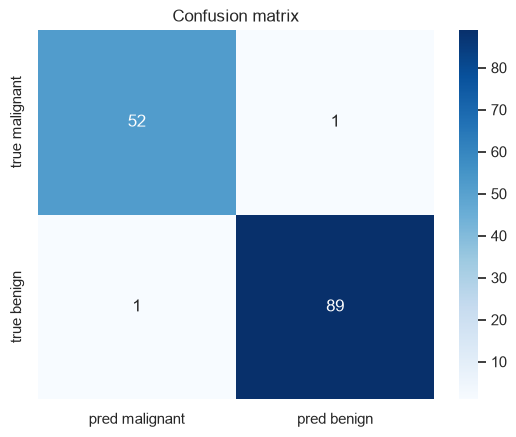

In [2]:
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target            # 1 = benign, 0 = malignant

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)
model = Pipeline([("sc", StandardScaler()),
                  ("m", LogisticRegression(max_iter=5000))]).fit(X_tr, y_tr)
pred = model.predict(X_te)

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()                   # sklearn order!

story = pd.DataFrame({
    "count": [tp, fn, fp, tn],
    "plain English": [
        "correctly flagged malignant",
        "MISSED cancer (worst case!)",
        "false alarm on healthy patient",
        "correctly cleared healthy"],
}, index=["TP", "FN", "FP", "TN"])
display(story.T)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred malignant", "pred benign"],
            yticklabels=["true malignant", "true benign"])
plt.title("Confusion matrix"); plt.show()

## 2. Precision & recall - who should fear which error?

$$\text{precision}=\frac{TP}{TP+FP}\;\;(\text{of my alarms, how many were real?})
\qquad \text{recall}=\frac{TP}{TP+FN}\;\;(\text{of all fires, how many did I catch?})$$

- **Spam filter**: false positives hide real email → demand HIGH PRECISION.
- **Cancer screen**: false negatives kill → demand HIGH RECALL.

In [3]:
prec = precision_score(y_te, pred)      # for class 'benign' here
rec = recall_score(y_te, pred)
f1 = f1_score(y_te, pred)

print(f"accuracy : {accuracy_score(y_te, pred):.4f}")
print(f"precision: {prec:.4f}   (flagged-benign patients truly benign)")
print(f"recall   : {rec:.4f}   (truly-benign patients caught)")
print(f"F1       : {f1:.4f}   (harmonic mean - punishes lopsidedness)")
print("\n⚠️ For MALIGNANT detection flip the view: recall_malignant =",
      round(recall_score(y_te, pred, pos_label=0), 4))

accuracy : 0.9860
precision: 0.9889   (flagged-benign patients truly benign)
recall   : 0.9889   (truly-benign patients caught)
F1       : 0.9889   (harmonic mean — punishes lopsidedness)

⚠️ For MALIGNANT detection flip the view: recall_malignant = 0.9811


## 3. The threshold knob - 0.5 is a DEFAULT, not a law

`predict()` uses p ≥ 0.5. But probabilities give us freedom:
raise the bar → fewer alarms, more misses; lower it → catch everything, cry wolf.

,threshold,precision,recall,F1
0,0.20,0.957,1.000,0.978
1,0.35,0.968,1.000,0.984
2,0.50,0.989,0.989,0.989
3,0.65,0.988,0.944,0.966
4,0.80,0.988,0.933,0.960


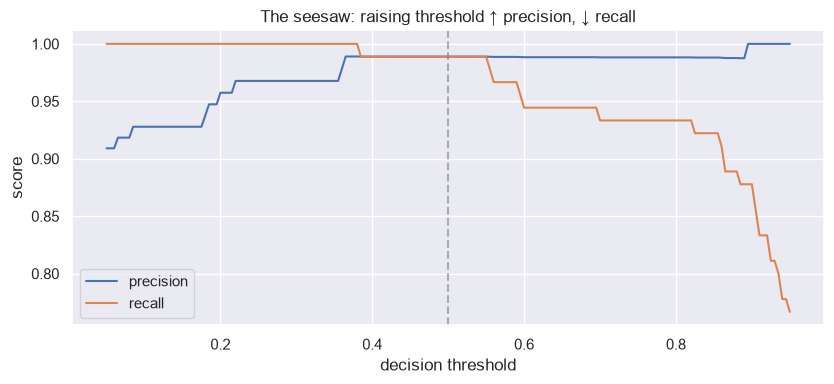

In [4]:
proba = model.predict_proba(X_te)[:, 1]

rows = []
for t in [0.2, 0.35, 0.5, 0.65, 0.8]:
    lab = (proba >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": round(precision_score(y_te, lab), 3),
                 "recall   ": round(recall_score(y_te, lab), 3),
                 "F1": round(f1_score(y_te, lab), 3)})
display(pd.DataFrame(rows))

ths = np.linspace(0.05, 0.95, 181)
precs, recs = [], []
for t in ths:
    lab = (proba >= t).astype(int)
    precs.append(precision_score(y_te, lab))
    recs.append(recall_score(y_te, lab))

plt.figure(figsize=(8.5, 4))
plt.plot(ths, precs, label="precision")
plt.plot(ths, recs, label="recall")
plt.axvline(.5, ls="--", c="gray", alpha=.6)
plt.xlabel("decision threshold"); plt.ylabel("score")
plt.title("The seesaw: raising threshold ↑ precision, ↓ recall")
plt.legend(); plt.tight_layout(); plt.show()

## 4. ROC & AUC - quality across ALL thresholds at once

ROC sweeps every threshold and plots hit-rate vs false-alarm-rate.
**AUC = area under it**: 0.5 = coin flip, 1.0 = perfect ordering of patients.

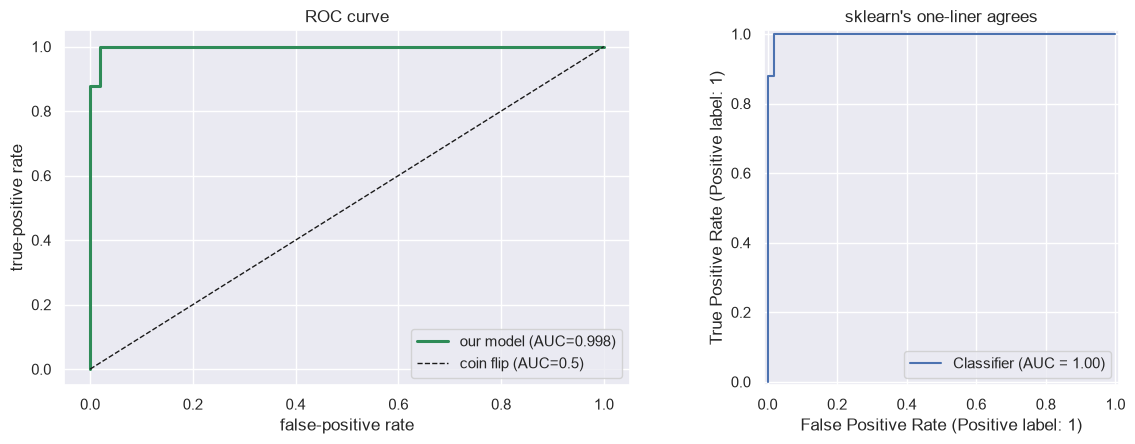

In [5]:
fpr, tpr, _ = roc_curve(y_te, proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].plot(fpr, tpr, lw=2.2, color="seagreen",
             label=f"our model (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="coin flip (AUC=0.5)")
axes[0].set_xlabel("false-positive rate"); axes[0].set_ylabel("true-positive rate")
axes[0].set_title("ROC curve"); axes[0].legend()

RocCurveDisplay.from_predictions(y_te, proba, ax=axes[1])
axes[1].set_title("sklearn's one-liner agrees")

plt.tight_layout(); plt.show()

### AUC intuition in one line

*Pick one random sick patient and one random healthy one: AUC = probability the
model gives the sicker one a higher risk score.*

## 5. Class imbalance trap - why accuracy fooled us

Make the problem artificially imbalanced (keep only 10% of benign cases) and
watch accuracy become meaningless:

In [6]:
mask_keep_benign = np.random.RandomState(0).rand((y_tr == 1).sum()) < 0.10
idx = np.r_[np.where(y_tr == 0)[0], np.where(y_tr == 1)[0][mask_keep_benign]]
np.random.RandomState(42).shuffle(idx)

imbal_model = Pipeline([("sc", StandardScaler()),
                        ("m", LogisticRegression(max_iter=5000))]) \
                     .fit(X_tr.iloc[idx], y_tr.iloc[idx])

lazy_pred = np.ones(len(y_te))                # 'always predict benign' strategy!
print(f"class balance after subsampling train: "
      f"{y_tr.iloc[idx].value_counts(normalize=True).round(2).to_dict()}")
print(f"lazy always-1 accuracy: {(lazy_pred == y_te).mean():.3f}"
      f"  ← looks decent, catches ZERO cancers")
print(f"real model accuracy  : {imbal_model.score(X_te, y_te):.3f}")
print("→ with imbalance, READ THE CONFUSION MATRIX / AUC, never accuracy alone.")

class balance after subsampling train: {0: 0.86, 1: 0.14}
lazy always-1 accuracy: 0.629  ← looks decent, catches ZERO cancers
real model accuracy  : 0.846
→ with imbalance, READ THE CONFUSION MATRIX / AUC, never accuracy alone.


## Summary & key takeaways

- Confusion matrix first: TP/FN/FP/TN tell the whole story in four numbers.
- **Precision** protects against false alarms; **recall** protects against
  misses; **F1** balances; pick by BUSINESS cost.
- The threshold is a business dial, not a constant - slide it deliberately.
- ROC-AUC measures ranking quality independent of any threshold.
- Under class imbalance, accuracy can flatter a useless model.